---
## 0 — Imports & Configuration

In [65]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Paths
ROOT = Path('..') 
DATA = ROOT / 'data'

# ── Toggleable configuration ──────────────────────────────────────────────────
LOOKBACK    = 28          # days of history fed to LSTM
HORIZONS    = range(1, 8) # h = 1..7 days ahead
LSTM_UNITS  = 64
DROPOUT     = 0.2
EPOCHS      = 200
BATCH_SIZE  = 32
PATIENCE    = 15
LR          = 0.001

WINSOR_LO   = 0.05
WINSOR_HI   = 0.95

# Exogenous variables
EXOG_HOURLY = [
    'wind_day_ahead_mw',
    'day_ahead_load_forecast_mw',
    'net_import_de_mw',
    'net_import_dk2_mw',
    'net_import_mw'
]
EXOG_DAILY = [
    'gas_price',
    'coal_price',
    'oil_price',
    'eua_price',
]

EXOG_ALL = EXOG_HOURLY + EXOG_DAILY

# Forecast window
ORIGIN     = pd.Timestamp('2023-12-31')
TEST_START = pd.Timestamp('2024-01-01')
TEST_END   = pd.Timestamp('2024-01-07')
VAL_DAYS   = 90  # days reserved for validation (early stopping)

print(f'TensorFlow {tf.__version__}')
print(f'Config: LOOKBACK={LOOKBACK}, LSTM_UNITS={LSTM_UNITS}, DROPOUT={DROPOUT}')
print(f'        EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}, PATIENCE={PATIENCE}')

TensorFlow 2.21.0
Config: LOOKBACK=28, LSTM_UNITS=64, DROPOUT=0.2
        EPOCHS=200, BATCH_SIZE=32, PATIENCE=15


In [66]:
# ── Evaluation helpers ─────────────────────────────────────────────────────────
def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    # Exclude near-zero actuals (|price| < 1 EUR/MWh) to avoid division blow-up
    mask = np.abs(y_true) > 1.0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred, label=''):
    m1, m2, m3 = mae(y_true, y_pred), rmse(y_true, y_pred), mape(y_true, y_pred)
    print(f'{label:>20s}  MAE={m1:7.2f}  RMSE={m2:7.2f}  MAPE={m3:5.1f}%')
    return {'MAE': m1, 'RMSE': m2, 'MAPE': m3}

---
## 1 — Load & Prepare Data

In [67]:
# Load hourly data
raw = pd.read_csv(
    DATA / 'hourly_features.csv',
    parse_dates=['ts_utc'],
    index_col='ts_utc',
)
raw.index = raw.index.tz_localize('UTC')

# Forward-fill commodity / macro columns (daily or lower frequency)
ffill_cols = ['coal_price', 'oil_price', 'gas_price', 'eua_price',
              'msci_eu', 'eurostoxx50', 'vix', 'usd_eur',
              'dk_cpi', 'dk_energy_cpi', 'gdp_denmark', 'gdp_euro_area']
raw[ffill_cols] = raw[ffill_cols].ffill()

# Extract date and hour
raw['date'] = raw.index.date
raw['date'] = pd.to_datetime(raw['date'])
raw['hour'] = raw.index.hour

print(f'Loaded: {raw.shape[0]} rows, {raw.shape[1]} columns')
print(f'Date range: {raw.index.min()} to {raw.index.max()}')

Loaded: 61368 rows, 33 columns
Date range: 2018-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00


In [68]:
# ── Pivot prices to daily-wide (date × 24 hours) ─────────────────────────────
price_wide = raw.pivot_table(
    index='date', columns='hour',
    values='day_ahead_price_eur_mwh', aggfunc='first'
)
price_wide.columns.name = None
print(f'Price wide: {price_wide.shape}  (dates × hours)')

# ── Pivot hourly exogenous to daily-wide (date × 24 hours each) ──────────────
# Each variable gets 24 columns: {var}_h00, {var}_h01, ..., {var}_h23
exog_hourly_wide_frames = []
for col in EXOG_HOURLY:
    col_wide = raw.pivot_table(index='date', columns='hour', values=col, aggfunc='first')
    col_wide.columns = [f'{col}_h{h:02d}' for h in range(24)]
    exog_hourly_wide_frames.append(col_wide)

exog_hourly_wide = pd.concat(exog_hourly_wide_frames, axis=1)
exog_hourly_wide = exog_hourly_wide.ffill().bfill()
print(f'Exog hourly wide: {exog_hourly_wide.shape}  ({len(EXOG_HOURLY)} vars × 24 hours)')

# ── Daily exogenous (scalar per day) ─────────────────────────────────────────
exog_scalar = pd.DataFrame(index=price_wide.index)
for col in EXOG_DAILY:
    exog_scalar[col] = raw.groupby('date')[col].first()
exog_scalar = exog_scalar.ffill().bfill()

# ── Weekend and holiday dummies (separate effects) ────────────────────────────
exog_scalar['is_weekend'] = raw.groupby('date')['is_weekend'].first().astype(float)
exog_scalar['is_holiday'] = raw.groupby('date')['is_holiday'].first().astype(float)

# ── Month dummies (drop January as reference, matching Panel OLS) ─────────────
month_dummies = pd.get_dummies(exog_scalar.index.month, prefix='month', drop_first=True, dtype=float)
month_dummies.index = exog_scalar.index
exog_scalar = pd.concat([exog_scalar, month_dummies], axis=1)

print(f'Exog scalar: {exog_scalar.shape}  ({list(exog_scalar.columns)})')

Price wide: (2557, 24)  (dates × hours)
Exog hourly wide: (2557, 120)  (5 vars × 24 hours)
Exog scalar: (2557, 17)  (['gas_price', 'coal_price', 'oil_price', 'eua_price', 'is_weekend', 'is_holiday', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12'])


In [69]:
# ── Build daily feature matrix ────────────────────────────────────────────────
# Each row = one date, columns = [24 prices | 24×N_hourly exog | daily scalars]
daily_matrix = pd.concat([price_wide, exog_hourly_wide, exog_scalar], axis=1)
daily_matrix = daily_matrix.dropna()

feature_names = list(daily_matrix.columns)
N_FEATURES = len(feature_names)

n_price = 24
n_hourly_exog = len(EXOG_HOURLY) * 24
n_scalar = len(exog_scalar.columns)
print(f'Daily feature matrix: {daily_matrix.shape}  ({N_FEATURES} features per day)')
print(f'  Prices:       {n_price}')
print(f'  Hourly exog:  {n_hourly_exog}  ({len(EXOG_HOURLY)} vars × 24h)')
print(f'  Scalars:      {n_scalar}  ({list(exog_scalar.columns)})')
print(f'Date range: {daily_matrix.index.min().date()} to {daily_matrix.index.max().date()}')

Daily feature matrix: (2557, 161)  (161 features per day)
  Prices:       24
  Hourly exog:  120  (5 vars × 24h)
  Scalars:      17  (['gas_price', 'coal_price', 'oil_price', 'eua_price', 'is_weekend', 'is_holiday', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12'])
Date range: 2018-01-01 to 2024-12-31


---
## 2 — Standardisation & Sequence Construction

In [70]:
def create_sequences(daily_values, price_values, horizon, lookback):
    """
    Build LSTM input/output pairs.
    
    Parameters
    ----------
    daily_values : np.ndarray, shape (N_days, N_features)
        Standardised daily feature matrix.
    price_values : np.ndarray, shape (N_days, 24)
        Raw (or winsorised+scaled) price wide matrix, aligned to same dates.
    horizon : int
        Forecast horizon in days.
    lookback : int
        Number of past days in each input sequence.
    
    Returns
    -------
    X : np.ndarray, shape (N_samples, lookback, N_features)
    y : np.ndarray, shape (N_samples, 24)
    indices : np.ndarray — date indices of the forecast origin for each sample
    """
    X, y, indices = [], [], []
    n = len(daily_values)
    for i in range(lookback, n - horizon):
        X.append(daily_values[i - lookback:i])       # L days of features
        y.append(price_values[i + horizon])            # price vector h days ahead
        indices.append(i)
    return np.array(X), np.array(y), np.array(indices)

print('Sequence constructor ready.')

Sequence constructor ready.


---
## 3 — Train / Validation Split & Scaling

In [71]:
# Determine training date range (same for all horizons for the input scaler)
all_dates = daily_matrix.index
train_end = ORIGIN  # last date whose features we use (Dec 31 2023)
train_mask = all_dates <= train_end

# Index of ORIGIN in the daily matrix
origin_idx = all_dates.get_loc(ORIGIN)
print(f'Origin index: {origin_idx}  ({ORIGIN.date()})')
print(f'Training dates: {all_dates[0].date()} to {all_dates[train_mask][-1].date()}')
print(f'Training days: {train_mask.sum()}')

Origin index: 2190  (2023-12-31)
Training dates: 2018-01-01 to 2023-12-31
Training days: 2191


In [72]:
# ── Fit scalers on training data only ─────────────────────────────────────────
daily_values = daily_matrix.values  # (N_days, N_features)
price_values = price_wide.reindex(daily_matrix.index).values  # (N_days, 24)

# Input scaler (all features including prices within the daily vector)
input_scaler = StandardScaler()
input_scaler.fit(daily_values[:origin_idx + 1])

# Output scaler (24 hourly prices)
output_scaler = StandardScaler()
output_scaler.fit(price_values[:origin_idx + 1])

# Scale inputs (full series — but scaler fitted only on training)
daily_scaled = input_scaler.transform(daily_values)
price_scaled = output_scaler.transform(price_values)

print(f'Input scaler fitted on {origin_idx + 1} days, {N_FEATURES} features')
print(f'Output scaler fitted on {origin_idx + 1} days, 24 hours')

Input scaler fitted on 2191 days, 161 features
Output scaler fitted on 2191 days, 24 hours


---
## 4 — Build & Train 7 LSTM Models

In [73]:
def build_model(lookback, n_features, lstm_units, dropout, lr):
    """Build a simple LSTM model: LSTM → Dropout → Dense(24)."""
    model = Sequential([
        LSTM(lstm_units, input_shape=(lookback, n_features)),
        Dropout(dropout),
        Dense(24),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

# Quick check
m = build_model(LOOKBACK, N_FEATURES, LSTM_UNITS, DROPOUT, LR)
m.summary()

Model: "sequential_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_46 (LSTM)                  │ (None, 64)             │        57,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,416 (232.09 KB)

 Trainable params: 59,416 (232.09 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
models = {}
histories = {}
winsor_bounds = {}

for h in HORIZONS:
    print(f'\n{"="*60}')
    print(f'Horizon h={h}  (predict {h} day(s) ahead)')
    print(f'{"="*60}')
    
    # ── Winsorise outcome on training data ────────────────────────────────
    train_prices_flat = price_values[LOOKBACK + h:origin_idx + 1].flatten()
    lo_bound = np.percentile(train_prices_flat, WINSOR_LO * 100)
    hi_bound = np.percentile(train_prices_flat, WINSOR_HI * 100)
    winsor_bounds[h] = (lo_bound, hi_bound)
    print(f'  Winsorisation bounds: [{lo_bound:.1f}, {hi_bound:.1f}] EUR/MWh')
    
    # Apply winsorisation to price_values (for outcome only)
    price_winsor = np.clip(price_values, lo_bound, hi_bound)
    out_scaler_h = StandardScaler()
    out_scaler_h.fit(price_winsor[:origin_idx + 1])
    price_w_scaled = out_scaler_h.transform(price_winsor)
    
    # ── Create sequences ──────────────────────────────────────────────────
    X_all, y_all, idx_all = create_sequences(
        daily_scaled, price_w_scaled, horizon=h, lookback=LOOKBACK
    )
    
    # Only keep samples where outcome is within training period
    valid_train = idx_all <= (origin_idx - h)
    X_train_full = X_all[valid_train]
    y_train_full = y_all[valid_train]
    
    n_total = len(X_train_full)
    n_val = min(VAL_DAYS, n_total // 5)
    n_train = n_total - n_val
    
    X_train, X_val = X_train_full[:n_train], X_train_full[n_train:]
    y_train, y_val = y_train_full[:n_train], y_train_full[n_train:]
    
    print(f'  Train: {n_train} samples, Val: {n_val} samples')
    
    # ── Phase 1: Find best epoch via early stopping on train/val split ────
    tf.random.set_seed(SEED + h)
    model_es = build_model(LOOKBACK, N_FEATURES, LSTM_UNITS, DROPOUT, LR)
    
    es = EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0
    )
    
    history = model_es.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[es, reduce_lr], verbose=0,
    )
    
    best_epoch = int(np.argmin(history.history['val_loss'])) + 1
    best_val = min(history.history['val_loss'])
    print(f'  Early stopping: best epoch = {best_epoch}, val_loss = {best_val:.6f}')
    
    # ── Phase 2: Retrain on ALL data (train + val) for best_epoch epochs ──
    tf.random.set_seed(SEED + h)
    model_final = build_model(LOOKBACK, N_FEATURES, LSTM_UNITS, DROPOUT, LR)
    
    history_final = model_final.fit(
        X_train_full, y_train_full,
        epochs=best_epoch, batch_size=BATCH_SIZE,
        verbose=0,
    )
    
    final_loss = history_final.history['loss'][-1]
    print(f'  Retrained on full data ({n_total} samples) for {best_epoch} epochs, loss = {final_loss:.6f}')
    
    models[h] = (model_final, out_scaler_h)
    histories[h] = history  # keep the ES history for plotting

print('\nAll 7 models trained.')


Horizon h=1  (predict 1 day(s) ahead)
  Winsorisation bounds: [5.0, 278.3] EUR/MWh
  Train: 2072 samples, Val: 90 samples
  Early stopping: best epoch = 7, val_loss = 0.327907
  Retrained on full data (2162 samples) for 7 epochs, loss = 0.200015

Horizon h=2  (predict 2 day(s) ahead)
  Winsorisation bounds: [5.0, 278.4] EUR/MWh
  Train: 2071 samples, Val: 90 samples
  Early stopping: best epoch = 4, val_loss = 0.343113
  Retrained on full data (2161 samples) for 4 epochs, loss = 0.257825

Horizon h=3  (predict 3 day(s) ahead)
  Winsorisation bounds: [5.0, 278.4] EUR/MWh
  Train: 2070 samples, Val: 90 samples
  Early stopping: best epoch = 7, val_loss = 0.406592
  Retrained on full data (2160 samples) for 7 epochs, loss = 0.208039

Horizon h=4  (predict 4 day(s) ahead)
  Winsorisation bounds: [5.0, 278.6] EUR/MWh
  Train: 2069 samples, Val: 90 samples
  Early stopping: best epoch = 3, val_loss = 0.446832
  Retrained on full data (2159 samples) for 3 epochs, loss = 0.289353

Horizon h=5

---
## 5 — Training History

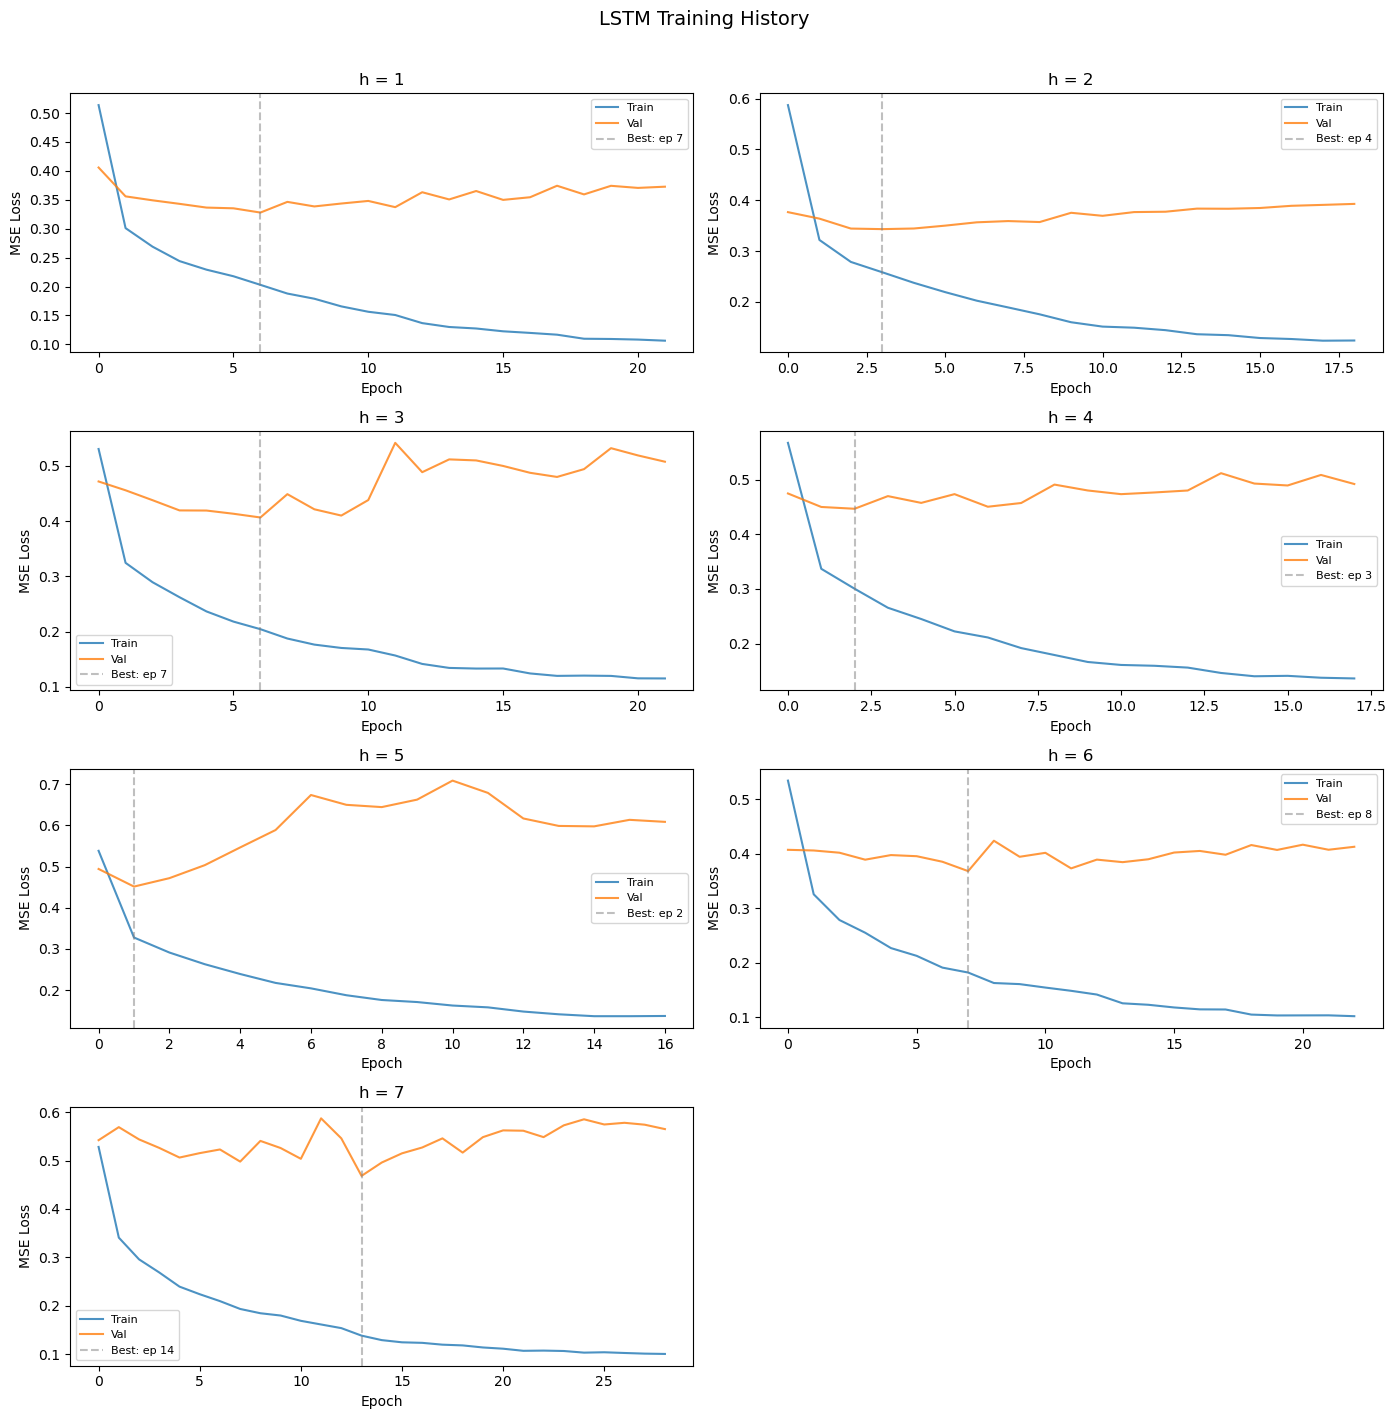

In [75]:
# ── Training loss curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for i, h in enumerate(HORIZONS):
    ax = axes[i]
    hist = histories[h].history
    ax.plot(hist['loss'], label='Train', alpha=0.8)
    ax.plot(hist['val_loss'], label='Val', alpha=0.8)
    best_ep = np.argmin(hist['val_loss'])
    ax.axvline(best_ep, color='grey', ls='--', alpha=0.5, label=f'Best: ep {best_ep+1}')
    ax.set_title(f'h = {h}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('LSTM Training History', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 6 — Generate Forecasts for Jan 1–7, 2024

In [76]:
# ── Build forecast input: 28-day window ending at ORIGIN (Dec 4–31, 2023) ─────
forecast_input = daily_scaled[origin_idx - LOOKBACK + 1:origin_idx + 1]  # shape (28, N_FEATURES)
forecast_input = forecast_input.reshape(1, LOOKBACK, N_FEATURES)          # shape (1, 28, N_FEATURES)

print(f'Forecast input shape: {forecast_input.shape}')
print(f'Window: {daily_matrix.index[origin_idx - LOOKBACK + 1].date()} to {daily_matrix.index[origin_idx].date()}')

# ── Predict for each horizon ─────────────────────────────────────────────────
forecast_rows = []
for h in HORIZONS:
    model_h, scaler_h = models[h]
    pred_scaled = model_h.predict(forecast_input, verbose=0)  # shape (1, 24)
    pred = scaler_h.inverse_transform(pred_scaled)             # back to EUR/MWh
    forecast_rows.append(pred.flatten())
    target_date = ORIGIN + pd.Timedelta(days=h)
    print(f'  h={h} -> {target_date.date()}  mean={pred.mean():.1f} EUR/MWh')

# ── Assemble forecast table (7 days × 24 hours) ──────────────────────────────
forecast_dates = pd.date_range(TEST_START, TEST_END, freq='D')
forecast_table = pd.DataFrame(
    forecast_rows, index=forecast_dates, columns=range(24)
)
forecast_table.index.name = 'date'

print(f'\nForecast table shape: {forecast_table.shape}')
forecast_table

Forecast input shape: (1, 28, 161)
Window: 2023-12-04 to 2023-12-31
  h=1 -> 2024-01-01  mean=49.9 EUR/MWh
  h=2 -> 2024-01-02  mean=81.8 EUR/MWh
  h=3 -> 2024-01-03  mean=53.0 EUR/MWh
  h=4 -> 2024-01-04  mean=56.7 EUR/MWh
  h=5 -> 2024-01-05  mean=58.7 EUR/MWh
  h=6 -> 2024-01-06  mean=46.1 EUR/MWh
  h=7 -> 2024-01-07  mean=56.5 EUR/MWh

Forecast table shape: (7, 24)


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,46.032639,31.658348,51.428436,9.730896,25.515804,30.421173,42.253811,64.015251,62.773346,54.557568,...,47.094063,50.453072,57.026539,48.659393,71.849007,65.118637,59.782738,59.610680,35.687088,49.597054
2024-01-02,64.165459,69.132317,67.492119,63.607479,57.080360,69.527855,95.124176,74.934296,82.197678,84.337914,...,78.190277,85.929527,98.879036,107.093239,128.429352,84.585861,100.579330,82.874313,78.409401,64.452866
2024-01-03,22.892281,27.969574,22.517906,43.821873,56.278774,20.605843,54.942932,70.195824,79.924736,56.626835,...,67.837204,72.015610,69.832909,68.810486,41.290390,60.199646,69.217155,64.971214,40.107521,30.376087
2024-01-04,34.647839,38.652939,38.534496,23.800716,36.125607,60.879734,55.266365,39.111492,64.066505,64.941605,...,64.779083,83.105125,58.639565,84.620338,66.451805,69.954704,59.135372,64.993744,53.821102,61.886322
2024-01-05,45.262627,49.341827,48.615856,35.512024,25.852558,46.074436,79.699661,64.460953,80.291504,70.259674,...,58.777817,76.601028,69.522690,64.420502,77.155716,26.249008,70.992569,67.063980,57.756958,37.580475
2024-01-06,30.335373,48.440132,19.464325,37.624237,37.034702,57.559105,56.651428,56.432335,45.909275,23.335537,...,58.539787,37.341648,53.264385,76.068047,64.184624,55.049168,66.591469,46.375038,41.265427,29.517052
2024-01-07,56.162071,53.988392,38.311806,46.433578,42.072571,61.616024,52.693535,66.481834,61.415527,40.858128,...,56.388412,73.530899,51.968365,69.266571,60.222771,55.646141,53.864494,47.841209,72.205734,70.328438


In [77]:
# ── Load actuals ──────────────────────────────────────────────────────────────
actual_table = price_wide.loc[TEST_START:TEST_END].copy()
actual_table.columns.name = None
print(f'Actual table shape: {actual_table.shape}')
actual_table

Actual table shape: (7, 24)


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,28.14,26.66,4.14,-0.03,-0.02,-0.05,-0.02,0.00,0.08,41.34,...,50.61,59.47,64.99,61.74,61.27,59.97,54.92,47.65,35.55,30.59
2024-01-02,20.07,31.03,18.39,11.08,13.78,47.63,58.10,65.67,64.73,68.98,...,79.96,81.46,80.92,74.95,63.18,57.11,46.89,40.00,21.81,1.04
2024-01-03,-0.01,0.00,-0.01,0.00,0.02,1.09,40.59,59.61,60.61,57.00,...,67.18,73.59,82.28,82.97,79.03,73.23,67.41,65.00,58.12,57.30
2024-01-04,50.46,40.00,25.48,35.00,57.73,72.65,85.02,91.47,94.20,91.61,...,98.62,105.73,133.23,144.65,125.00,103.59,100.01,94.86,88.83,86.08
2024-01-05,80.51,77.01,73.21,74.05,76.03,81.00,87.00,89.57,94.93,96.28,...,100.05,102.97,107.38,108.45,103.96,100.09,94.19,94.92,86.80,82.25
2024-01-06,80.20,76.13,73.01,73.01,74.59,75.10,81.39,88.40,92.23,97.30,...,95.09,99.85,104.69,103.84,99.31,92.23,88.00,86.75,80.03,86.15
2024-01-07,82.46,76.92,75.28,73.33,73.78,75.14,78.04,81.79,85.03,87.15,...,88.01,93.42,101.77,104.85,103.55,100.50,93.31,91.17,83.86,87.02


---
## 7 — Evaluation

In [78]:
# ── Overall metrics (all 168 forecasts) ───────────────────────────────────────
all_pred   = forecast_table.values.flatten()
all_actual = actual_table.values.flatten()

print('Overall (168 forecasts):')
overall = evaluate(all_actual, all_pred, 'Overall')

Overall (168 forecasts):
             Overall  MAE=  28.89  RMSE=  33.84  MAPE=100.3%


In [79]:
# ── Per-day metrics ───────────────────────────────────────────────────────────
day_metrics = []
for i, h in enumerate(HORIZONS):
    day_pred   = forecast_table.iloc[i].values
    day_actual = actual_table.iloc[i].values
    target_date = forecast_dates[i]
    m = evaluate(day_actual, day_pred, f'h={h} ({target_date.strftime("%a %b %d")})')
    m['horizon'] = h
    m['date'] = target_date
    day_metrics.append(m)

day_df = pd.DataFrame(day_metrics)
day_df

    h=1 (Mon Jan 01)  MAE=  19.19  RMSE=  26.00  MAPE= 86.9%
    h=2 (Tue Jan 02)  MAE=  30.38  RMSE=  36.27  MAPE=350.8%
    h=3 (Wed Jan 03)  MAE=  15.72  RMSE=  21.44  MAPE=109.5%
    h=4 (Thu Jan 04)  MAE=  30.98  RMSE=  35.25  MAPE= 34.6%
    h=5 (Fri Jan 05)  MAE=  32.50  RMSE=  34.93  MAPE= 36.0%
    h=6 (Sat Jan 06)  MAE=  42.87  RMSE=  45.21  MAPE= 48.1%
    h=7 (Sun Jan 07)  MAE=  30.58  RMSE=  32.56  MAPE= 34.8%


,MAE,RMSE,MAPE,horizon,date
0,19.188701,25.996882,86.943211,1,2024-01-01
1,30.380673,36.268550,350.804034,2,2024-01-02
2,15.723810,21.443943,109.501271,3,2024-01-03
3,30.977303,35.246690,34.573892,4,2024-01-04
4,32.499685,34.927331,36.047683,5,2024-01-05
5,42.874785,45.206501,48.081879,6,2024-01-06
6,30.580853,32.557887,34.824515,7,2024-01-07


In [80]:
# ── Per-hour metrics ──────────────────────────────────────────────────────────
hour_metrics = []
for k in range(24):
    h_pred   = forecast_table[k].values
    h_actual = actual_table[k].values
    m = evaluate(h_actual, h_pred, f'Hour {k:02d}')
    m['hour'] = k
    hour_metrics.append(m)

hour_df = pd.DataFrame(hour_metrics)
hour_df

             Hour 00  MAE=  30.30  RMSE=  32.64  MAPE= 75.4%
             Hour 01  MAE=  21.53  RMSE=  24.84  MAPE= 41.2%
             Hour 02  MAE=  35.30  RMSE=  38.10  MAPE=269.4%
             Hour 03  MAE=  31.16  RMSE=  34.56  MAPE=128.7%
             Hour 04  MAE=  38.02  RMSE=  39.81  MAPE=102.2%
             Hour 05  MAE=  21.38  RMSE=  22.80  MAPE=322.8%
             Hour 06  MAE=  25.83  RMSE=  28.18  MAPE= 34.2%
             Hour 07  MAE=  29.80  RMSE=  35.71  MAPE= 28.7%
             Hour 08  MAE=  30.60  RMSE=  34.71  MAPE= 30.7%
             Hour 09  MAE=  28.84  RMSE=  36.67  MAPE= 34.3%
             Hour 10  MAE=  25.56  RMSE=  30.50  MAPE= 30.6%
             Hour 11  MAE=  27.83  RMSE=  33.68  MAPE= 34.6%
             Hour 12  MAE=  23.82  RMSE=  29.51  MAPE= 28.6%
             Hour 13  MAE=  22.04  RMSE=  27.67  MAPE= 25.4%
             Hour 14  MAE=  21.32  RMSE=  27.26  MAPE= 22.9%
             Hour 15  MAE=  20.92  RMSE=  28.32  MAPE= 22.0%
             Hour 16  MA

,MAE,RMSE,MAPE,hour
0,30.301781,32.644261,75.412651,0
1,21.529564,24.839476,41.170024,1
2,35.297282,38.104742,269.418875,2
3,31.161385,34.560376,128.652294,3
4,38.019929,39.807277,102.194161,4
5,21.377939,22.796590,322.848932,5
6,25.827133,28.175180,34.224471,6
7,29.801251,35.705118,28.669803,7
8,30.597564,34.711464,30.709471,8
9,28.841958,36.669662,34.308952,9


---
## 8 — Visualisation

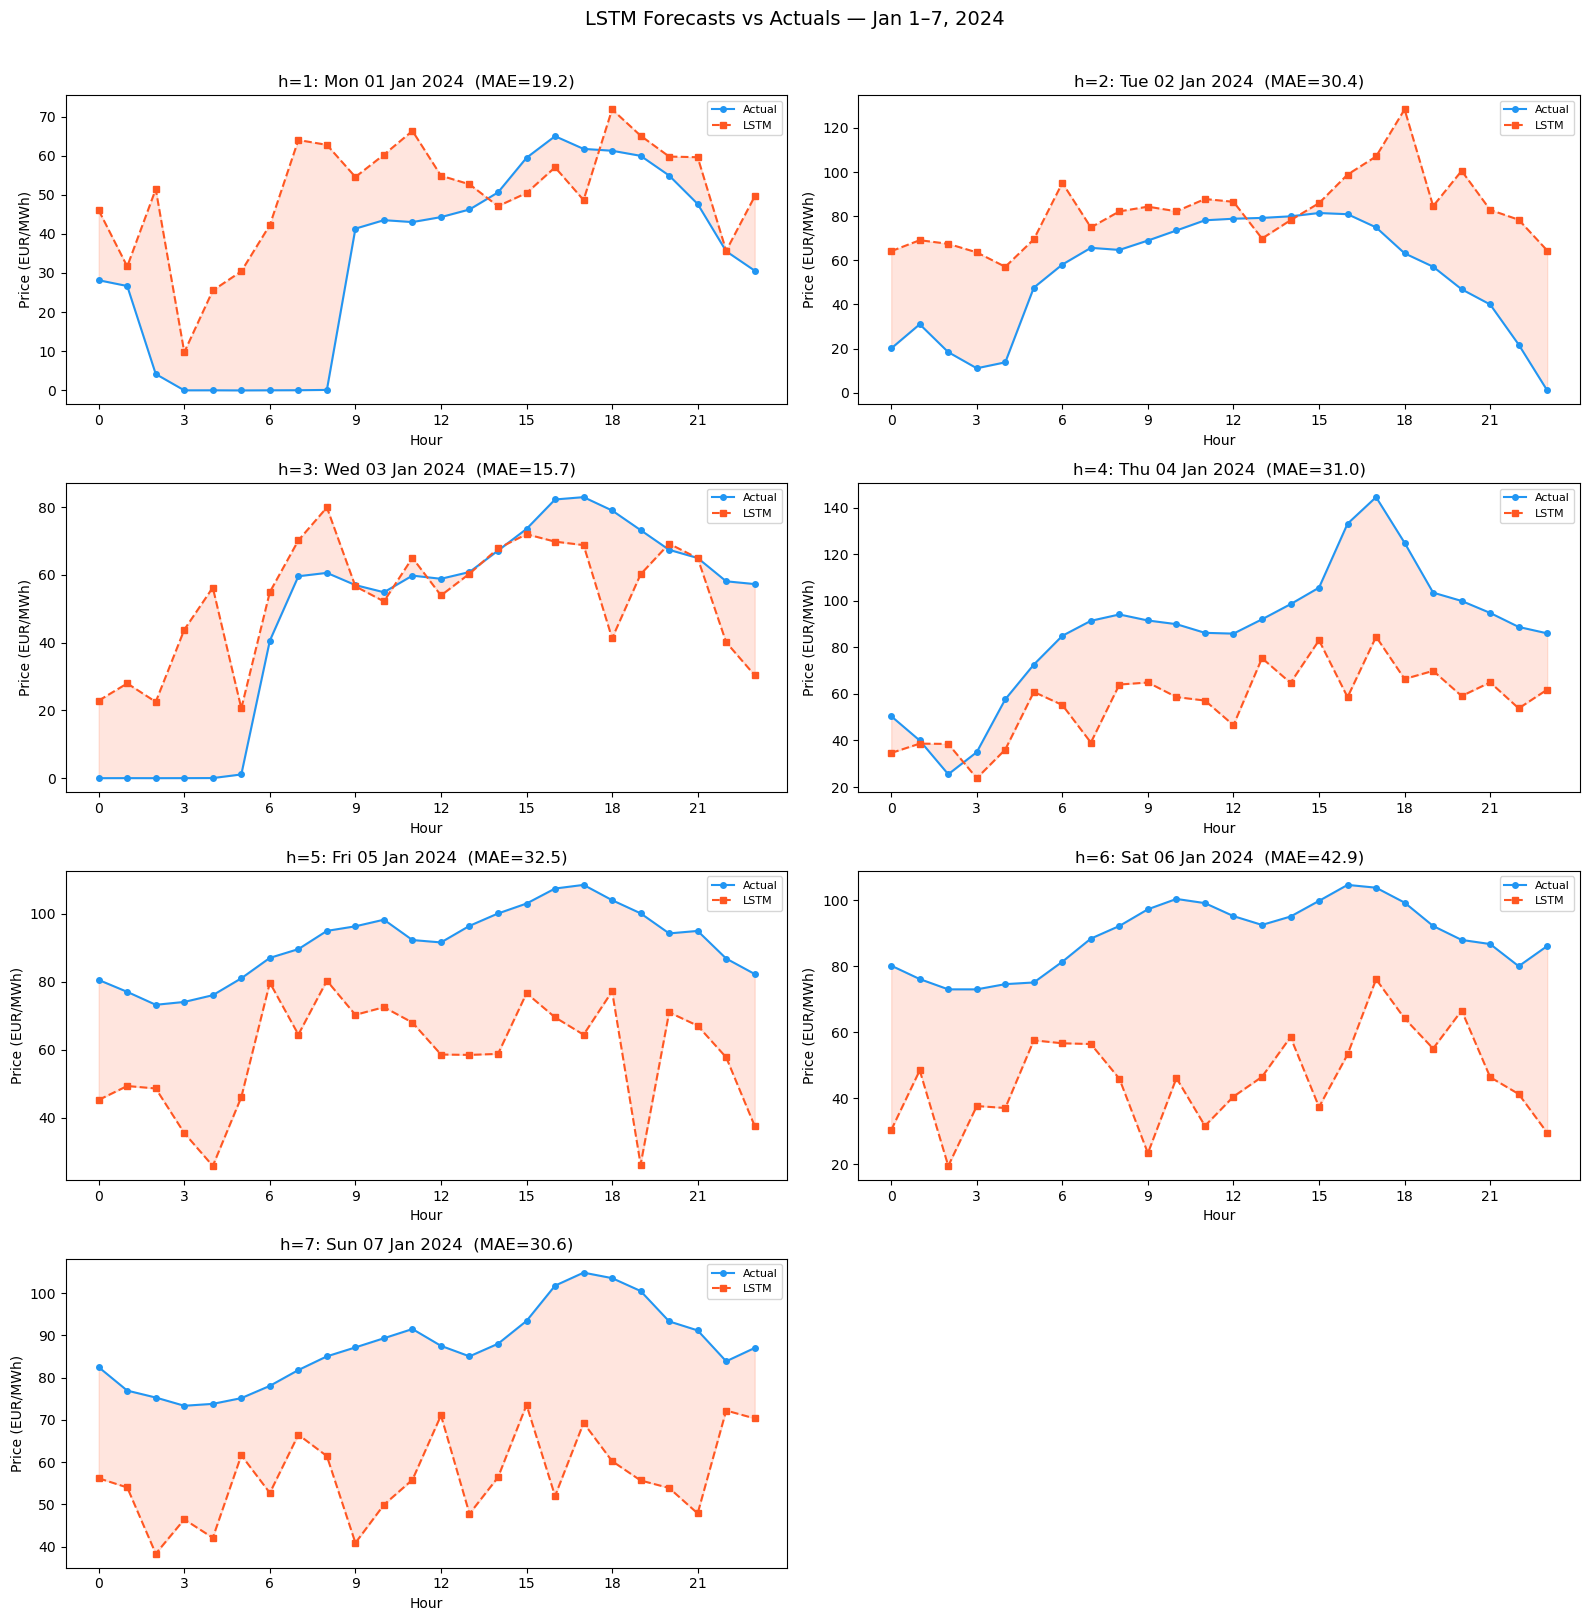

In [81]:
# ── Plot 1: Actual vs Predicted per day ───────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, h in enumerate(HORIZONS):
    ax = axes[i]
    target_date = forecast_dates[i]
    day_actual = actual_table.iloc[i].values
    day_pred   = forecast_table.iloc[i].values
    
    ax.plot(range(24), day_actual, 'o-', label='Actual', color='#2196F3', ms=4)
    ax.plot(range(24), day_pred, 's--', label='LSTM', color='#FF5722', ms=4)
    ax.fill_between(range(24), day_actual, day_pred, alpha=0.15, color='#FF5722')
    
    day_mae = mae(day_actual, day_pred)
    ax.set_title(f'h={h}: {target_date.strftime("%a %d %b %Y")}  (MAE={day_mae:.1f})')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Price (EUR/MWh)')
    ax.legend(fontsize=8)
    ax.set_xticks(range(0, 24, 3))

axes[-1].set_visible(False)
fig.suptitle('LSTM Forecasts vs Actuals — Jan 1–7, 2024', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

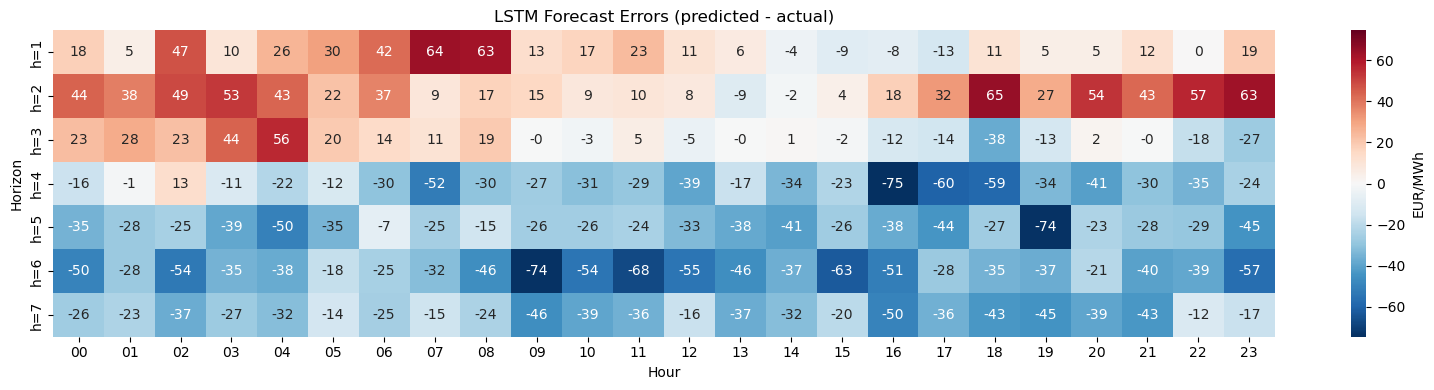

In [83]:
# ── Plot 2: Forecast error heatmap (7 days × 24 hours) ────────────────────────
error_table = forecast_table.values - actual_table.values
error_df = pd.DataFrame(
    error_table,
    index=[f'h={h}' for h in HORIZONS],
    columns=[f'{k:02d}' for k in range(24)]
)

fig, ax = plt.subplots(figsize=(16, 4))
vabs = max(abs(error_table.min()), abs(error_table.max()))
sns.heatmap(
    error_df, cmap='RdBu_r', center=0, vmin=-vabs, vmax=vabs,
    annot=True, fmt='.0f', ax=ax, cbar_kws={'label': 'EUR/MWh'}
)
ax.set_title('LSTM Forecast Errors (predicted - actual)')
ax.set_xlabel('Hour')
ax.set_ylabel('Horizon')
plt.tight_layout()
plt.show()

---
## 9 — Export

In [ ]:
# ── Export forecast table ─────────────────────────────────────────────────────
export = forecast_table.copy()
export.columns = [f'hour_{k:02d}' for k in range(24)]
export.to_csv('lstm_forecast_task1.csv')
print('Saved: analyses/lstm_forecast_task1.csv')

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\nLSTM Task 1 Summary:')
print(f'  Overall MAE:  {overall["MAE"]:.2f} EUR/MWh')
print(f'  Overall RMSE: {overall["RMSE"]:.2f} EUR/MWh')
print(f'  Overall MAPE: {overall["MAPE"]:.1f}%')
print(f'  Architecture: LSTM({LSTM_UNITS}) -> Dropout({DROPOUT}) -> Dense(24)')
print(f'  Lookback:     {LOOKBACK} days')
print(f'  Features:     {N_FEATURES} per day')